In [1]:
%%HTML
<style>
    div#notebook-container    { width: 95%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }
</style>

In [ ]:
from __future__ import print_function, division
import sys,os
# line 4 and line 5 below are for development purposes and ca be removed
qspin_path = os.path.join(os.getcwd(),"../../")
sys.path.insert(0,qspin_path)
from quspin.operators import hamiltonian # Hamiltonians and operators
#from quspin.basis import spinless_fermion_basis_1d # Hilbert space fermion basis
from quspin.basis import spin_basis_1d # Hilbert space spin basis
import numpy as np # generic math functions
import matplotlib.pyplot as plt # plotting library
from scipy.linalg import expm, sinm, cosm
from numpy.linalg import multi_dot
from scipy.sparse import csr_matrix, csc_matrix, coo_matrix, lil_matrix
from scipy.sparse.linalg import inv, eigs
from scipy.linalg import svdvals
from scipy.stats import unitary_group
from scipy import linalg
from numpy import linalg as LA
import pylab
import time
import numba
from numba import njit,c16,i8,u2
import sys
import math

np.set_printoptions(precision=2)
np.set_printoptions(suppress=True)
np.set_printoptions(threshold=np.inf, linewidth=np.inf)

time_sta = time.time()

####################
#cilyinder geometry#
####################

#################################################
def create_transformation_pv_link(Ld,Lx,Ly):
#############################################
############ plaquette part #################
#############################################
    #p_indd = np.zeros((Lx*Ly,4),dtype='uint32')
    p_indd=[]
    for ip in range(Lx*(Ly)):
        ix,iy = ip%Lx,ip//Lx
        if iy==0:
            p_indd+=[[ix+Ld,ix+Lx+Ld,((ix+1)%Lx)+Ld]]
            #print(ip,ix,ix+Lx,((ix+1)%Lx)) 
        elif iy==Ly-1:
            p_indd+=[[ix+(Lx)+(2*Lx)*(iy-1)+Ld,ix+(Lx)+(2*Lx)*(iy-1)+Lx+Ld,ix+3*Lx+(2*Lx)*(iy-1)+Ld,(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx+Ld]]
            #print(ip,ix+(Lx)+(2*Lx)*(iy-1),ix+(Lx)+(2*Lx)*(iy-1)+Lx,(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx)
        else:
            p_indd+=[[ix+(Lx)+(2*Lx)*(iy-1)+Ld,ix+(Lx)+(2*Lx)*(iy-1)+Lx+Ld,ix+(Lx)+(2*Lx)*(iy-1)+(2*Lx)+Ld,(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx+Ld]]       
            #print(ip,ix+(Lx)+(2*Lx)*(iy-1),ix+(Lx)+(2*Lx)*(iy-1)+Lx,ix+(Lx)+(2*Lx)*(iy-1)+(2*Lx),(ix+1)%Lx+(Lx)+(2*Lx)*(iy-1)+Lx)
    #sys.exit()
###########  Here, we add Ld to an index to simplify determining a binary representation
###########  In other words, Ld corresponds to the shift in a binary representation
###########  since plaquette parts are pauli Z operator

############################################
############ vertex part ###################
############################################
    #v_indd = np.zeros(((Lx+1)*(Ly-1),4),dtype='uint32')
    v_indd =[]
    for iv in range((Lx)*(Ly)):
        ix,iy = iv%(Lx),iv//(Lx)
        if ix==0:
            if iy==Ly-1:
                v_indd+=[[iy*(2*Lx),(iy+1)*(2*Lx)-1,iy*(2*Lx)+Lx]]
                #print(iv,iy*(2*Lx),(iy+1)*(2*Lx)-1,(iy+1)*(2*Lx),iy*(2*Lx)+Lx)
            else:
                v_indd+=[[iy*(2*Lx),(iy+1)*(2*Lx)-1,(iy+1)*(2*Lx),iy*(2*Lx)+Lx]]
        else:
            if iy==Ly-1:
                v_indd+=[[ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix+iy*(2*Lx)+Lx]]
            else:
                v_indd+=[[ix+iy*(2*Lx),ix+iy*(2*Lx)+Lx-1,ix+(iy+1)*(2*Lx),ix+iy*(2*Lx)+Lx]]
    #sys.exit()
    return p_indd,v_indd

#################################################################
def initial_stabilizer_state(Ld,Lxd,Lyd,p_ind,v_ind):
    # Ld: total # of qubits
    MRi=np.zeros((Ld,2*Ld+1),dtype='uint32')
    #print(2*Ld+1)
############################################
####### plaquette stabilizers ZZZZ #########
############################################
    for ip in range(Lxd*Lyd):
        MRi[ip][p_ind[ip]]=1 # neglect a phase factor
        #print(999,ip,p_ind[ip])
    #sys.exit()
############################################
###### vertex stabilizers  XXXX #############
############################################
    for iv in range((Lxd)*(Lyd)):
        ivs=iv+(Lxd*(Lyd))  # note that iv and ivs are different.
        MRi[ivs][v_ind[iv]]=1 # neglect a phase factor
        #print(ivs)
    #sys.exit()
    return MRi

def measurement_op(dMR,Ld,Lxd,Lyd,Gcd,mp,p_ind,v_ind):
    Meo=np.zeros(2*Ld+1,dtype='uint32')    
    if mp==1:
        ##Av measurement part
        vsite_list=np.arange((Lxd)*(Lyd)) #all vertex site
        vmd = np.random.choice(vsite_list, 1, replace=True)
        #print(vmd)
        Meo[v_ind[vmd[0]]]=1
    if mp==2:
        ##Bp measurement part
        psite_list=np.arange((Lxd)*(Lyd)) #all vertex site
        pmd = np.random.choice(psite_list, 1, replace=True)
        #print(pmd)
        Meo[p_ind[pmd[0]]]=1
    if mp==3:
        #local X
        site_list=np.arange(0,Ld-Lxd) #eliminate (low)smooth boundary
        md = np.random.choice(site_list, 1, replace=True)
        Meo[md]=1 #X
        # outcome 
        todo=[0,2]
        prob_list = [0.5,0.5]
        outcome = np.random.choice(todo,size=None,replace=True, p=prob_list)
        Meo[2*Ld] = outcome #factor +1 or -1 
    if mp==4:
        #local Z
        site_list=np.arange(Lxd,Ld) #eliminate (upper) rough boundary 
        md = np.random.choice(site_list, 1, replace=True)
        Meo[md+Ld]=1 #Z
        # outcome 
        todo=[0,2]
        prob_list = [0.5,0.5]
        outcome = np.random.choice(todo,size=None,replace=True, p=prob_list)
        Meo[2*Ld] = outcome #factor +1 or -1 
    
    # Meo without outcome sign
    MeoF=np.zeros(2*Ld,dtype='uint32')
    MeoF=Meo[0:2*Ld]
    
    # dMR without foctor
    dMRF=np.zeros((Ld,2*Ld),dtype='uint32')
    dMRF=dMR[:,0:2*Ld]
    #check anti commtation
    Mgs=np.dot(dMRF,np.dot(Gcd,MeoF.T))
    Mgs=Mgs%2  ## check: reduce Z2 value 
    
    antic_index_list=[]
    aid=np.where(Mgs[:]!=0)
    antic_index_list=aid[0]
    #######
    lenMe=len(antic_index_list)
    if lenMe !=0:
        kc=antic_index_list[0]
        dMR_prev=dMR[kc].copy()
        #replace stabilizer for kc
        dMR[kc]=Meo
        update_list=np.delete(antic_index_list,0)
        dMR[update_list,:]=np.mod(dMR[update_list,:]+dMR_prev,2)
        ## sigh_factorのupdateは今は何でもよい
    return dMR



##############################################################
def factor_update(P1,P2,Ldd):
    r1 = P1[2*Ldd]
    r2 = P2[2*Ldd]
    
    r1r2d = r1 + r2
    for j in range(Ldd):
        z1j=P1[j+Ldd]
        x1j=P1[j]
        z2j=P2[j+Ldd]
        x2j=P2[j]
        
        if z1j==0 and x1j==0:
            gf=0
        if z1j==1 and x1j==1:
            gf=z2j-x2j
        if z1j==1 and x1j==0:
            gf=x2j*(1-2*z2j)
        if z1j==0 and x1j==1:
            gf=z2j*(2*x2j-1)
        r1r2d = r1r2d + gf
    r1r2d=r1r2d%4
    return r1r2d


###############################################################################
def SGOZ_create(Ld,Lxd,Lyd):
################################################################
################################################################
#######  ### rough boundary ZZ correlation ### #################
################################################################
################################################################
    SGZ_ij=np.zeros((2*Ld,Lxd*Lxd),dtype='uint32')
    SGZ_i=np.zeros((2*Ld,Lxd*Lxd),dtype='uint32')
    SGZ_j=np.zeros((2*Ld,Lxd*Lxd),dtype='uint32')
#####  # ZiZj operation: #######
    i=0
    for jf in range (Lxd):
        for ji in range(Lxd):
            SGZ_ij[ji+Ld,i]=1
            SGZ_ij[jf+Ld,i]=1
####  #Zi operation: ###########
            SGZ_i[Ld+ji,i]=1
##### # Zj operation: ##########
            SGZ_j[Ld+jf,i]=1
            i+=1
    SGZ_ij_csr= csr_matrix(SGZ_ij)
    SGZ_i_csr = csr_matrix(SGZ_i)
    SGZ_j_csr = csr_matrix(SGZ_j)
    return SGZ_ij_csr,SGZ_i_csr,SGZ_j_csr

###############################################################################
###############################################################################
def SGOZ_cal_rdep(dMR,Lxd,Gcd_csr,SGZ_ij_csr,SGZ_i_csr,SGZ_j_csr):
################################################################
#######  ### rough boundary ZZ correlation ### #################
################################################################
#####  # ZiZj operation: #######
    dMR_csr = csr_matrix(dMR)
    Mgs=(dMR_csr.dot(Gcd_csr.dot(SGZ_ij_csr))).toarray()
    SGZ_ij=np.all((Mgs%2)<0.1,axis=0)
    #print(ij.astype(int),"ij")
####  #Zi operation: ###########
    Mgs=(dMR_csr.dot(Gcd_csr.dot(SGZ_i_csr))).toarray()
    SGZ_i=np.all((Mgs%2)<0.1,axis=0)
    #print(i.astype(int),"i")
##### # Zj operation: ##########
    Mgs=(dMR_csr.dot(Gcd_csr.dot(SGZ_j_csr))).toarray()
    SGZ_j=np.all((Mgs%2)<0.1,axis=0)
    #print(j.astype(int),"j")
    chiSGZ=np.sum(SGZ_ij.astype(int)-SGZ_i.astype(int)*SGZ_j.astype(int))/(Lxd) #       
    return chiSGZ


###############################################################################
def SGOX_create(Ld,Lxd,Lyd):
################################################################
################################################################
#######  ### rough boundary ZZ correlation ### #################
################################################################
################################################################
    SGX_ij=np.zeros((2*Ld,Lxd*Lxd),dtype='uint32')
    SGX_i=np.zeros((2*Ld,Lxd*Lxd),dtype='uint32')
    SGX_j=np.zeros((2*Ld,Lxd*Lxd),dtype='uint32')
#####  # ZiZj operation: #######
    i=0
    for jf in range (Lxd):
        for ji in range(Lxd):
            SGX_ij[ji+Ld-Lx,i]=1
            SGX_ij[jf+Ld-Lx,i]=1
####  #Zi operation: ###########
            SGX_i[Ld+ji-Lx,i]=1
##### # Zj operation: ##########
            SGX_j[Ld+jf-Lx,i]=1
            i+=1
    SGX_ij_csr= csr_matrix(SGX_ij)
    SGX_i_csr = csr_matrix(SGX_i)
    SGX_j_csr = csr_matrix(SGX_j)
    return SGX_ij_csr,SGX_i_csr,SGX_j_csr

###############################################################################
###############################################################################
def SGOX_cal_rdep(dMR,Lxd,Gcd_csr,SGX_ij_csr,SGX_i_csr,SGX_j_csr):
################################################################
#######  ### rough boundary ZZ correlation ### #################
################################################################
#####  # ZiZj operation: #######
    dMR_csr = csr_matrix(dMR)
    Mgs=(dMR_csr.dot(Gcd_csr.dot(SGX_ij_csr))).toarray()
    SGX_ij=np.all((Mgs%2)<0.1,axis=0)
    #print(ij.astype(int),"ij")
####  #Zi operation: ###########
    Mgs=(dMR_csr.dot(Gcd_csr.dot(SGX_i_csr))).toarray()
    SGX_i=np.all((Mgs%2)<0.1,axis=0)
    #print(i.astype(int),"i")
##### # Zj operation: ##########
    Mgs=(dMR_csr.dot(Gcd_csr.dot(SGX_j_csr))).toarray()
    SGX_j=np.all((Mgs%2)<0.1,axis=0)
    #print(j.astype(int),"j")
    chiSGX=np.sum(SGX_ij.astype(int)-SGX_i.astype(int)*SGX_j.astype(int))/(Lxd) #       
    return chiSGX


#################################################
def create_partition_TEE(Ld,Lx,Ly,p_indd):
#############################################
############ plaquette part #################
#############################################
    A_indd=set()
    dhw=4
    dvw=3
    for iy in range(2,Ly-1,1):
        for ix in range(0,dhw,1):
            ip=ix+iy*Lx
            A_indd.update(p_indd[ip])
            
    B_indd=set()
    for iy in range(2,Ly-1,1):
        for ix in range(Lx-2-dhw,Lx-2,1):
            ip=ix+iy*Lx
            B_indd.update(p_indd[ip])
    
    C_indd=set()
    for iy in range(2,2+dvw,1):
        for ix in range(dhw,Lx-2-dhw,1):
            ip=ix+iy*Lx
            C_indd.update(p_indd[ip])    
    for iy in range(Ly-1-dvw,Ly-1,1):
        for ix in range(dhw,Lx-2-dhw,1):
            ip=ix+iy*Lx
            C_indd.update(p_indd[ip])
    C_indd=C_indd-A_indd-B_indd## elimination of elements included in A_indd and B_indd from C_indd
    AB_indd=A_indd.union(B_indd)
    AC_indd=A_indd.union(C_indd)
    BC_indd=B_indd.union(C_indd)
    ABC_indd=A_indd.union(B_indd,C_indd)
    A_indd=list(A_indd)
    A_indd+=[x-Ld for x in A_indd]
    B_indd=list(B_indd)
    B_indd+=[x-Ld for x in B_indd]
    C_indd=list(C_indd)
    C_indd+=[x-Ld for x in C_indd]
    AB_indd=list(AB_indd)
    AB_indd+=[x-Ld for x in AB_indd]
    BC_indd=list(BC_indd)
    BC_indd+=[x-Ld for x in BC_indd]
    AC_indd=list(AC_indd)
    AC_indd+=[x-Ld for x in AC_indd]
    ABC_indd=list(ABC_indd)
    ABC_indd+=[x-Ld for x in ABC_indd]
    return A_indd, B_indd, C_indd,AB_indd, AC_indd, BC_indd,ABC_indd 
#####################################
#################################################
def create_partition_TEE2(Ld,Lx,Ly,p_indd):
#############################################
############ plaquette part #################
#############################################
    dhw=(Lx-2)//3
    Lv=Ly-3
    A_indd=set()
    for iy in range(2,Ly-1,1):
        for ix in range(0,dhw,1):
            ip=ix+iy*Lx
            A_indd.update(p_indd[ip])
    
    C_indd=set()
    for iy in range(2+Lv//2+1,Ly-1,1):
        for ix in range(dhw,Lx-2,1):
            ip=ix+iy*Lx
            C_indd.update(p_indd[ip])    
    C_indd=C_indd-A_indd

    B_indd=set()
    for iy in range(2,2+Lv//2+1,1):
        for ix in range(dhw,Lx-2,1):
            ip=ix+iy*Lx
            B_indd.update(p_indd[ip])    
    B_indd=B_indd-A_indd-C_indd
        
    C_indd=C_indd-A_indd-B_indd## elimination of elements included in A_indd and B_indd from C_indd
    AB_indd=A_indd.union(B_indd)
    AC_indd=A_indd.union(C_indd)
    BC_indd=B_indd.union(C_indd)
    ABC_indd=A_indd.union(B_indd,C_indd)
    A_indd=list(A_indd)
    A_indd+=[x-Ld for x in A_indd]
    B_indd=list(B_indd)
    B_indd+=[x-Ld for x in B_indd]
    C_indd=list(C_indd)
    C_indd+=[x-Ld for x in C_indd]
    AB_indd=list(AB_indd)
    AB_indd+=[x-Ld for x in AB_indd]
    BC_indd=list(BC_indd)
    BC_indd+=[x-Ld for x in BC_indd]
    AC_indd=list(AC_indd)
    AC_indd+=[x-Ld for x in AC_indd]
    ABC_indd=list(ABC_indd)
    ABC_indd+=[x-Ld for x in ABC_indd]
    return A_indd, B_indd, C_indd,AB_indd, AC_indd, BC_indd,ABC_indd 
#####################################

def TEE_cal(MRFd,A_indd,B_indd,C_indd,AB_indd,AC_indd,BC_indd,ABC_indd):
    # partition AC#
    rankAC=rank_mod2_v3(MRFd[:,AC_indd].copy())
    SAC=rankAC-(len(AC_indd)//2)
######################
    rankAB=rank_mod2_v3(MRFd[:,AB_indd].copy())
    SAB=rankAB-(len(AB_indd)//2)
######################
    rankBC=rank_mod2_v3(MRFd[:,BC_indd].copy())
    SBC=rankBC-(len(BC_indd)//2)
######################
    rankABC=rank_mod2_v3(MRFd[:,ABC_indd].copy())
    SABC=rankABC-(len(ABC_indd)//2)
######################
    rankC=rank_mod2_v3(MRFd[:,C_indd].copy())
    SC=rankC-(len(C_indd)//2)
    rankB=rank_mod2_v3(MRFd[:,B_indd].copy())
    SB=rankB-(len(B_indd)//2)
    rankA=rank_mod2_v3(MRFd[:,A_indd].copy())
    SA=rankA-(len(A_indd)//2)
    TEE=SA+SB+SC-SAC-SBC-SAB+SABC
    return TEE

#######################################################################
def rank_mod2_v3(MRdd):
    # MRdA construct
    i = 0
    Ic = MRdd.shape[0]
    Jc = MRdd.shape[1]
    for j in range(Jc):
        check_ind=np.where(MRdd[i:,j]==1)
        if len(check_ind[0]) !=0:
            if len(check_ind[0]) >1:
                elim_ind=np.delete(check_ind,0)
                MRdd[elim_ind+i,:]=np.mod(MRdd[elim_ind+i,:]+MRdd[check_ind[0][0]+i,:],2)
            MRdd[i,:],MRdd[check_ind[0][0]+i,:] = MRdd[check_ind[0][0]+i,:],MRdd[i,:].copy()
            i=i+1
    return i
############################

#######################################################
#######################################################
#################     Main part   #####################
#######################################################
#######################################################
start=time.time()
#set the system size 
Lx_list=[14,18,22]
#Lx_list=[18]
#Lx=14
data_set = {}
for Lx in Lx_list:
    start=time.time()
    Ly=11
    L=2*Lx*Ly # total # of link qubits
    Ntot=10*L
    Nt=200
    Nt_list=np.round(np.linspace(0,Ntot,Nt+1, endpoint=True))
    #print(Nt_list[0:10],Nt_list[-10:-1])
    #print(Nt_list)
    px=0.5
    pz=0.5
    p_non=0.0
    #Create plaquette and vertex lebels --> four or three surrouding link site labels
    p_ind, v_ind = create_transformation_pv_link(L,Lx,Ly)
    ###########
    ## TEE1 ###
    ###########
    A_ind,B_ind,C_ind,AB_ind, AC_ind, BC_ind,ABC_ind=create_partition_TEE(L,Lx,Ly,p_ind)
    ###########
    ## TEE2 ###
    ###########
    A2_ind,B2_ind,C2_ind,AB2_ind, AC2_ind, BC2_ind,ABC2_ind=create_partition_TEE2(L,Lx,Ly,p_ind)
    #check matrix
    Gc=np.zeros((2*L,2*L),dtype='uint32') # 2L * 2L matrix
    for k in range(L):
        Gc[k][L+k]=1
        Gc[L+k][k]=1  
    ###################
    Gc_csr=csr_matrix(Gc)
    ####
    SGZ_ij_csr,SGZ_i_csr,SGZ_j_csr=SGOZ_create(L,Lx,Ly)
    SGX_ij_csr,SGX_i_csr,SGX_j_csr=SGOX_create(L,Lx,Ly)
    ####
    Nd = 150 # sample number
    SGZchi_ave_list=[]
    SGZchi_var_list=[]
    SGXchi_ave_list=[]
    SGXchi_var_list=[]
    #ps_list=[0.1,0.3,0.60,0.65,0.70]
    ps_list=[0.8]
    #fig5, ax5 = plt.subplots(figsize=(6,5))
    for ip in range(len(ps_list)):
        ps=ps_list[ip]
        print(px)
        SGZchi_list=np.zeros((Nd,Nt+1))
        SGXchi_list=np.zeros((Nd,Nt+1))
        topoEE_list=np.zeros((Nd,Nt+1))
        topoEE2_list=np.zeros((Nd,Nt+1))
        # stabilizer matrix
        MR=np.zeros((L,2*L+1),dtype='uint32') # L * 2L+1 matrix, 2*L+1 = constant factor 
        MRF=np.zeros((L,2*L),dtype='uint32') # L * 2L matrix
        print(Ntot)
        for ids in range(Nd):
            #print(ip,ids)
            MR=initial_stabilizer_state(L,Lx,Ly,p_ind,v_ind) #
            MRF=MR[:,0:2*L]
            dt=0
            topoEE_list[ids,dt]=TEE_cal(MRF,A_ind,B_ind,C_ind,AB_ind, AC_ind, BC_ind,ABC_ind)
            topoEE2_list[ids,dt]=TEE_cal(MRF,A2_ind,B2_ind,C2_ind,AB2_ind, AC2_ind, BC2_ind,ABC2_ind)
    ##############################
    ##############################
            #measurement
            for it in range(Ntot): 
                todo=[1,2] #1:Gauss's layer, 2: Matter layer
                prob_list = [ps,1-ps]
                mtype= np.random.choice(todo,size=None,replace=True, p=prob_list)
                if mtype==1:
                    todo=[1,2] #3:Av, 4:Bp
                    prob_list = [0.5,0.5]
                    mtype= np.random.choice(todo,size=None,replace=True, p=prob_list)
                else:
                    todo=[3,4] #3:X, 4:Z
                    prob_list = [px,pz]
                    mtype= np.random.choice(todo,size=None,replace=True, p=prob_list)
                MR=measurement_op(MR,L,Lx,Ly,Gc,mtype,p_ind,v_ind) #,prob_d_list,d_list)
    ############################################
    #############################################
                if np.any(Nt_list==it+1):
                    dt+=1
                    MRF=MR[:,0:2*L] # eliminate factor elements
                    SGZchi_list[ids,dt]=SGOZ_cal_rdep(MRF,Lx,Gc_csr,SGZ_ij_csr,SGZ_i_csr,SGZ_j_csr)
                    SGXchi_list[ids,dt]=SGOX_cal_rdep(MRF,Lx,Gc_csr,SGX_ij_csr,SGX_i_csr,SGX_j_csr)
                    topoEE_list[ids,dt]=TEE_cal(MRF,A_ind,B_ind,C_ind,AB_ind, AC_ind, BC_ind,ABC_ind)
                    topoEE2_list[ids,dt]=TEE_cal(MRF,A2_ind,B2_ind,C2_ind,AB2_ind, AC2_ind, BC2_ind,ABC2_ind)
        SGZchi_ave=np.mean(SGZchi_list,axis=0)
        SGZchi_var=np.var(SGZchi_list,axis=0)
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        data_set[key1+"_chiSGZ_ave"] =SGZchi_ave
        data_set[key1+"_chiSGZ_var"] =SGZchi_var        
    #################################################
        SGXchi_ave=np.mean(SGXchi_list,axis=0)
        SGXchi_var=np.var(SGXchi_list,axis=0)
        data_set[key1+"_chiSGX_ave"] =SGXchi_ave
        data_set[key1+"_chiSGX_var"] =SGXchi_var        
    #################################################
        topoEE_ave=np.mean(topoEE_list,axis=0)
        topoEE_var=np.var(topoEE_list,axis=0)
        data_set[key1+"_topoEE_ave"] =topoEE_ave
        data_set[key1+"_topoEE_var"] =topoEE_var        
        #################################################
        topoEE2_ave=np.mean(topoEE2_list,axis=0)
        topoEE2_var=np.var(topoEE2_list,axis=0)
        data_set[key1+"_topoEE2_ave"] =topoEE2_ave
        data_set[key1+"_topoEE2_var"] =topoEE2_var        
    print(time.time()-start) 
#np.savez_compressed('data_set.npz', **data_set)
np.savez_compressed('data_set3.npz', **data_set)
print("end")

0.5
3080
1350.1650891304016
0.5
3960
1942.1392939090729
0.5
4840
2666.174088001251
end


201


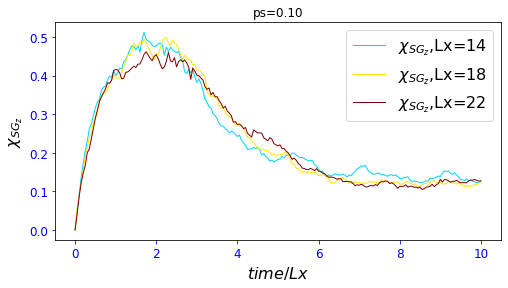

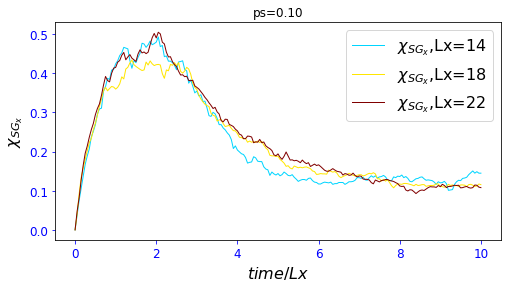

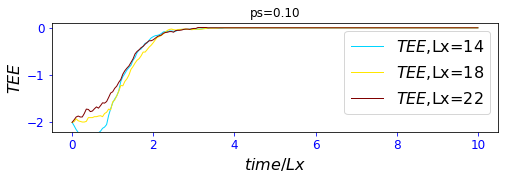

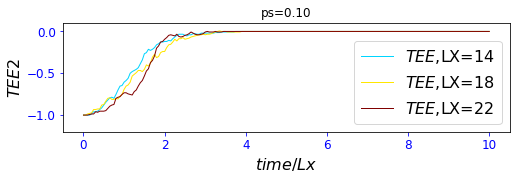

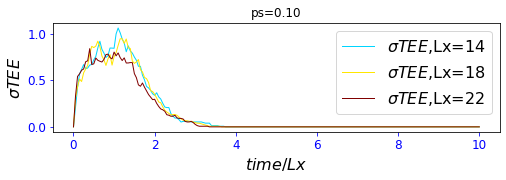

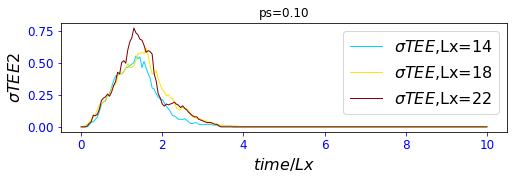

201


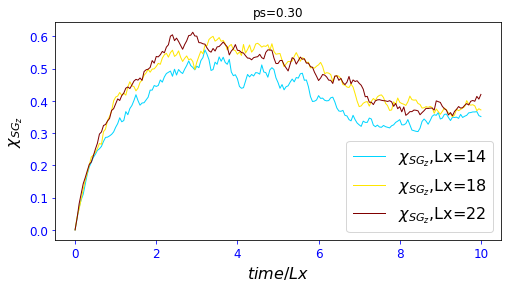

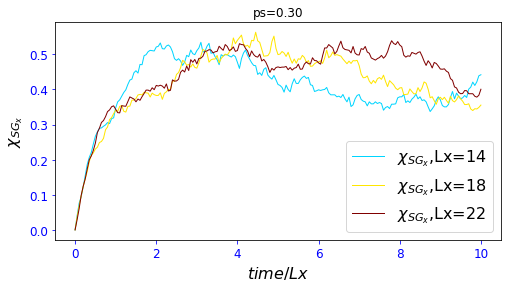

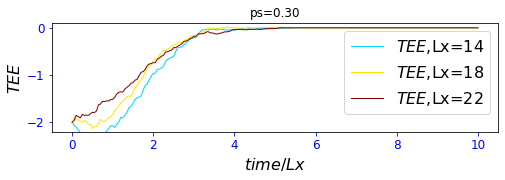

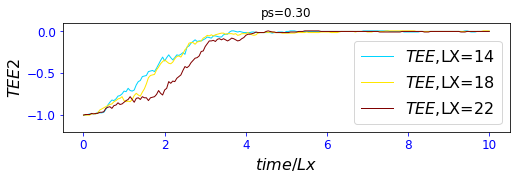

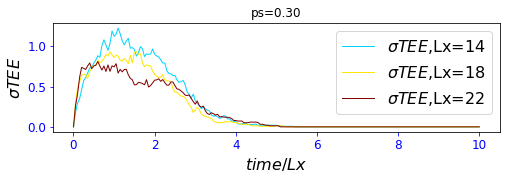

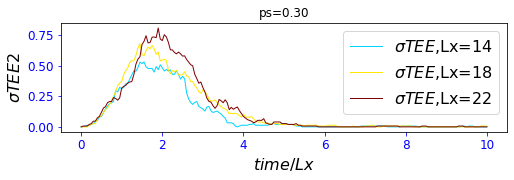

201


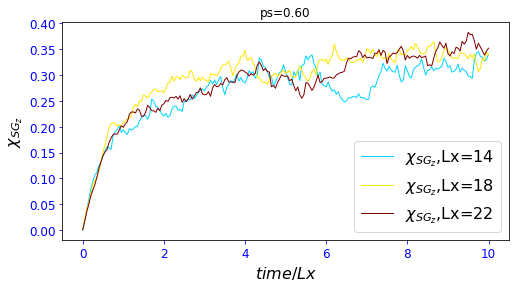

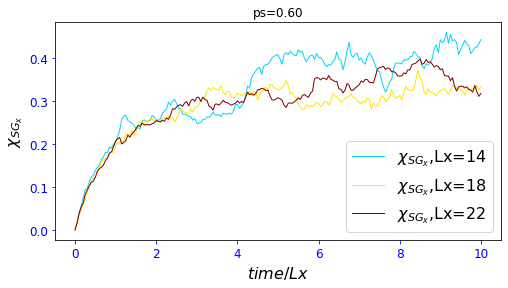

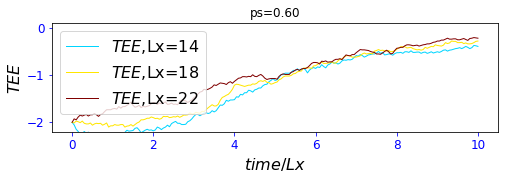

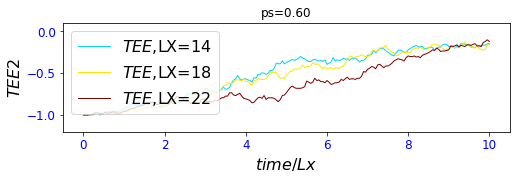

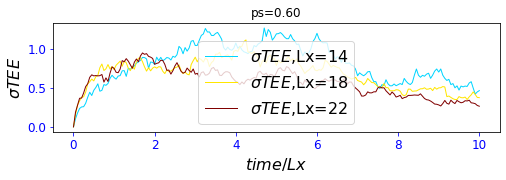

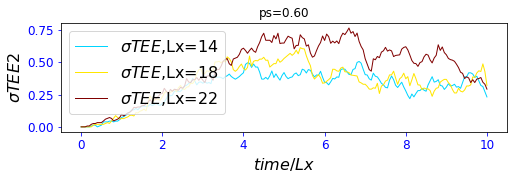

201


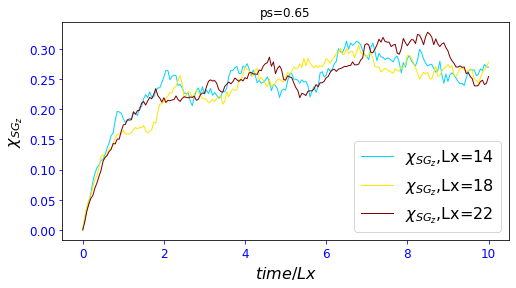

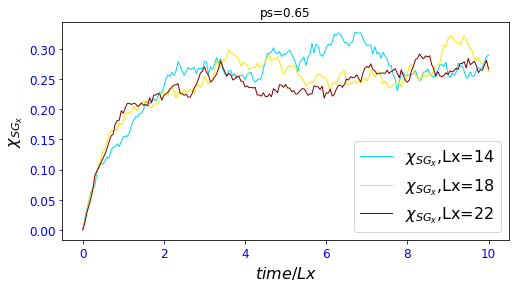

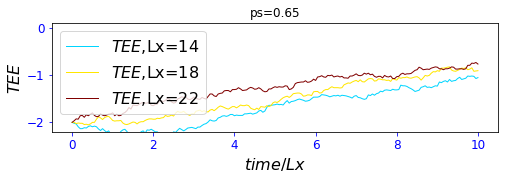

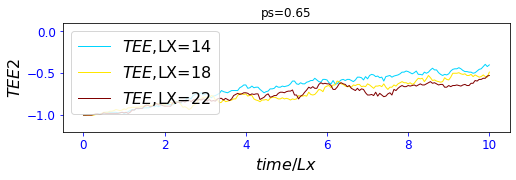

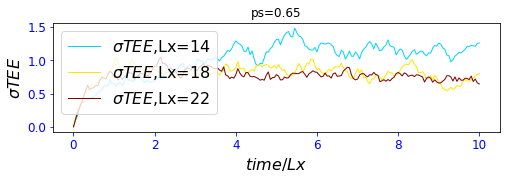

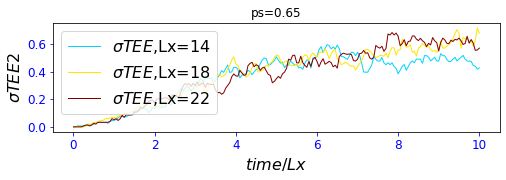

201


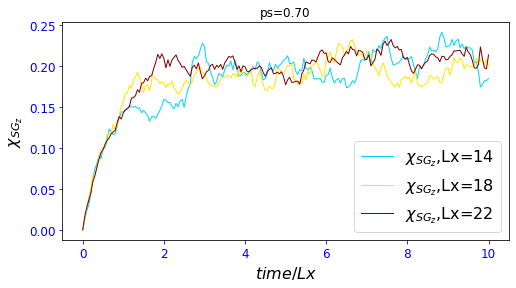

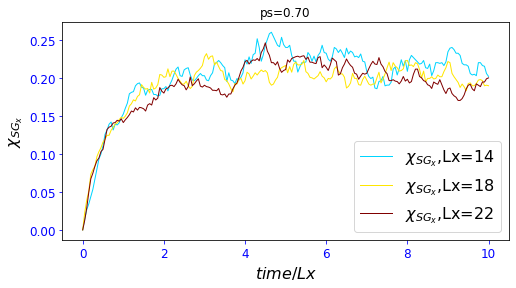

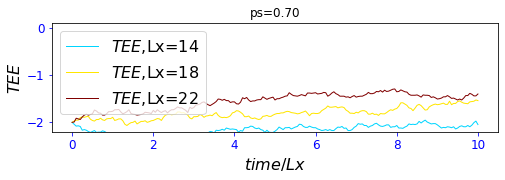

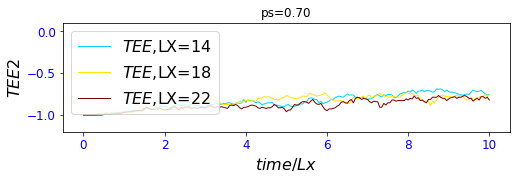

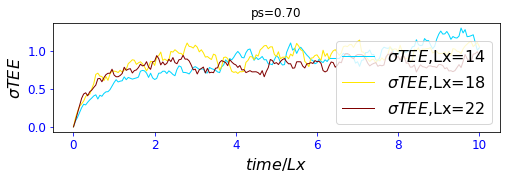

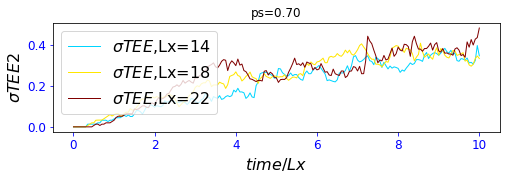

In [34]:
from __future__ import print_function, division
import sys,os
# line 4 and line 5 below are for development purposes and ca be removed
qspin_path = os.path.join(os.getcwd(),"../../")
sys.path.insert(0,qspin_path)
from quspin.operators import hamiltonian # Hamiltonians and operators
#from quspin.basis import spinless_fermion_basis_1d # Hilbert space fermion basis
from quspin.basis import spin_basis_1d # Hilbert space spin basis
import numpy as np # generic math functions
import matplotlib.pyplot as plt # plotting library
from scipy.linalg import expm, sinm, cosm
import matplotlib.cm as cm
from numba import njit,c16,i8,u2
import sys
import math
Lx=14
Lx_list=[14,18,22]
Ly=11
L=2*Lx*Ly # total # of link qubits
Ntot=10*L
Nt=200
time_list=np.linspace(0,10,Nt+1, endpoint=True)
#px=0.3
#pz=0.3
#p_non=0.4
px=0.5
pz=0.5
p_non=0.0
ps_list=[0.1,0.3,0.60,0.65,0.70]
#time_list=np.arange(Nt+1)
np.set_printoptions(precision=2)
np.set_printoptions(suppress=True)
data_set= np.load('data_set.npz')
for ps in ps_list:
    fig5, ax5 = plt.subplots(figsize=(8,4))
    print(len(time_list))
    pi=0
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$\chi_{SG_z}$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        #plt.ylim(0.0,4.5)
        plt.title("ps="+"{:.2f}".format(ps))
        ax5.plot(time_list,data_set[key1+"_chiSGZ_ave"],label=r"$\chi_{SG_z}$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ),lw=1)
        #ax5.plot(time_list,chiSGX_ave,label=r"$\chi_{SG_x}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='o', lw=1,markersize=10)
        plt.legend(fontsize=16)
    plt.show()
    pi=0
    fig5, ax5 = plt.subplots(figsize=(8,4))
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$\chi_{SG_x}$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        #plt.ylim(0.0,3.5)
        plt.title("ps="+"{:.2f}".format(ps))
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_chiSGX_ave"],label=r"$\chi_{SG_x}$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ), lw=1)
        plt.legend(fontsize=16)
    plt.show()
    pi=0
    fig5, ax5 = plt.subplots(figsize=(8,2))
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$TEE$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        plt.title("ps="+"{:.2f}".format(ps))
        plt.ylim(-2.2,0.1)
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_topoEE_ave"],label=r"$TEE$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ),  lw=1)
        plt.legend(fontsize=16)
    plt.show()
    fig5, ax5 = plt.subplots(figsize=(8,2))
    pi=0
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$TEE2$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        plt.title("ps="+"{:.2f}".format(ps))
        plt.ylim(-1.2,0.1)
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_topoEE2_ave"],label=r"$TEE$"+",LX="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ), lw=1)
        plt.legend(fontsize=16)
    plt.show()
    fig5, ax5 = plt.subplots(figsize=(8,2))
    pi=0
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$\sigma TEE$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        plt.title("ps="+"{:.2f}".format(ps))
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_topoEE_var"],label=r"$\sigma TEE$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ), lw=1)
        plt.legend(fontsize=16)
    plt.show()
    fig5, ax5 = plt.subplots(figsize=(8,2))
    pi=0
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$\sigma TEE2$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        plt.title("ps="+"{:.2f}".format(ps))
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_topoEE2_var"],label=r"$\sigma TEE$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ), lw=1)
        plt.legend(fontsize=16)
    plt.show()

201


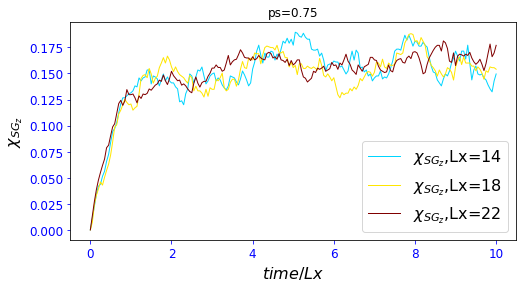

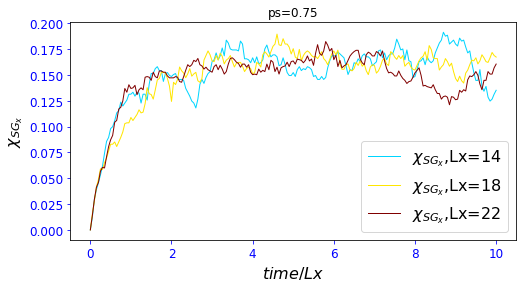

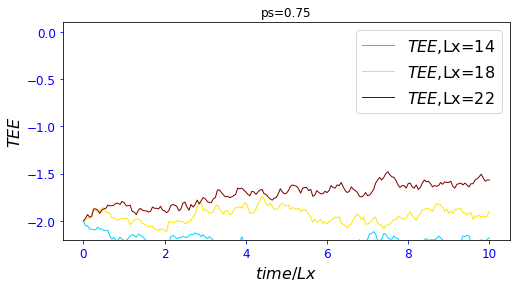

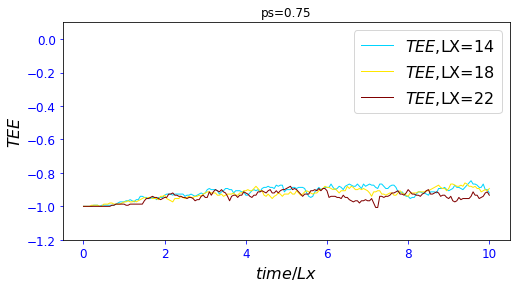

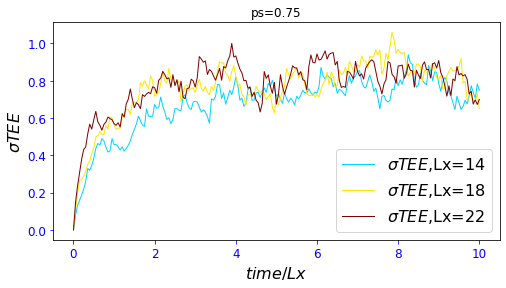

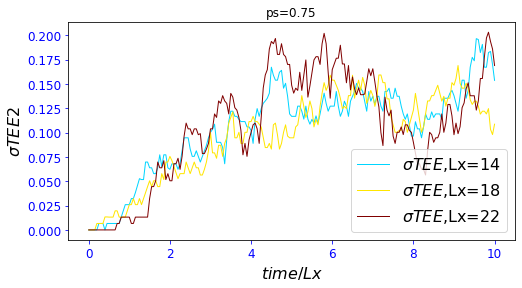

In [28]:
from __future__ import print_function, division
import sys,os
# line 4 and line 5 below are for development purposes and ca be removed
qspin_path = os.path.join(os.getcwd(),"../../")
sys.path.insert(0,qspin_path)
from quspin.operators import hamiltonian # Hamiltonians and operators
#from quspin.basis import spinless_fermion_basis_1d # Hilbert space fermion basis
from quspin.basis import spin_basis_1d # Hilbert space spin basis
import numpy as np # generic math functions
import matplotlib.pyplot as plt # plotting library
from scipy.linalg import expm, sinm, cosm
import matplotlib.cm as cm
from numba import njit,c16,i8,u2
import sys
import math
Lx=14
Lx_list=[14,18,22]
Ly=11
L=2*Lx*Ly # total # of link qubits
Ntot=10*L
Nt=200
time_list=np.linspace(0,10,Nt+1, endpoint=True)
#px=0.3
#pz=0.3
#p_non=0.4
px=0.5
pz=0.5
p_non=0.0
ps_list=[0.75]
#time_list=np.arange(Nt+1)
np.set_printoptions(precision=2)
np.set_printoptions(suppress=True)
data_set= np.load('data_set2.npz')
for ps in ps_list:
    fig5, ax5 = plt.subplots(figsize=(8,4))
    print(len(time_list))
    pi=0
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$\chi_{SG_z}$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        #plt.ylim(0.0,4.5)
        plt.title("ps="+"{:.2f}".format(ps))
        ax5.plot(time_list,data_set[key1+"_chiSGZ_ave"],label=r"$\chi_{SG_z}$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ),lw=1)
        #ax5.plot(time_list,chiSGX_ave,label=r"$\chi_{SG_x}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='o', lw=1,markersize=10)
        plt.legend(fontsize=16)
    plt.show()
    pi=0
    fig5, ax5 = plt.subplots(figsize=(8,4))
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$\chi_{SG_x}$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        #plt.ylim(0.0,3.5)
        plt.title("ps="+"{:.2f}".format(ps))
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_chiSGX_ave"],label=r"$\chi_{SG_x}$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ), lw=1)
        plt.legend(fontsize=16)
    plt.show()
    pi=0
    fig5, ax5 = plt.subplots(figsize=(8,4))
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$TEE$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        plt.title("ps="+"{:.2f}".format(ps))
        plt.ylim(-2.2,0.1)
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_topoEE_ave"],label=r"$TEE$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ),  lw=1)
        plt.legend(fontsize=16)
    plt.show()
    fig5, ax5 = plt.subplots(figsize=(8,4))
    pi=0
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$TEE$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        plt.title("ps="+"{:.2f}".format(ps))
        plt.ylim(-1.2,0.1)
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_topoEE2_ave"],label=r"$TEE$"+",LX="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ), lw=1)
        plt.legend(fontsize=16)
    plt.show()
    fig5, ax5 = plt.subplots(figsize=(8,4))
    pi=0
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$\sigma TEE$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        plt.title("ps="+"{:.2f}".format(ps))
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_topoEE_var"],label=r"$\sigma TEE$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ), lw=1)
        plt.legend(fontsize=16)
    plt.show()
    fig5, ax5 = plt.subplots(figsize=(8,4))
    pi=0
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$\sigma TEE2$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        plt.title("ps="+"{:.2f}".format(ps))
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_topoEE2_var"],label=r"$\sigma TEE$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ), lw=1)
        plt.legend(fontsize=16)
    plt.show()

201


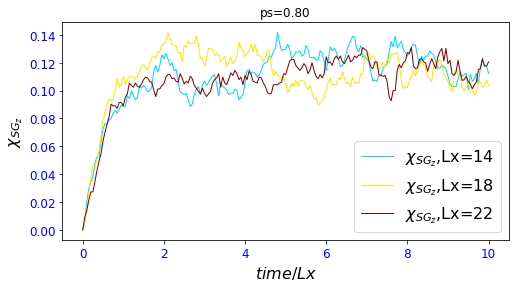

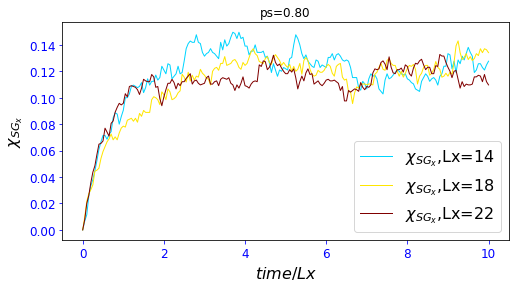

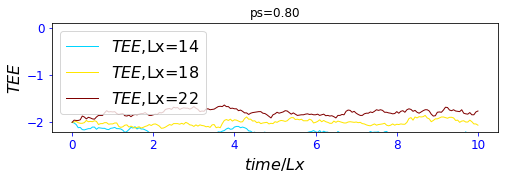

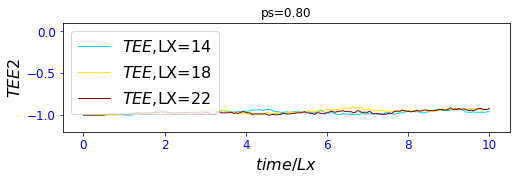

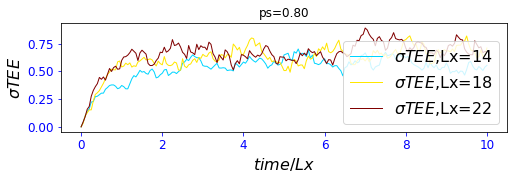

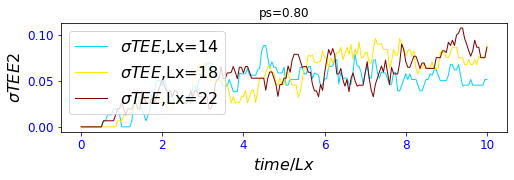

In [35]:
from __future__ import print_function, division
import sys,os
# line 4 and line 5 below are for development purposes and ca be removed
qspin_path = os.path.join(os.getcwd(),"../../")
sys.path.insert(0,qspin_path)
from quspin.operators import hamiltonian # Hamiltonians and operators
#from quspin.basis import spinless_fermion_basis_1d # Hilbert space fermion basis
from quspin.basis import spin_basis_1d # Hilbert space spin basis
import numpy as np # generic math functions
import matplotlib.pyplot as plt # plotting library
from scipy.linalg import expm, sinm, cosm
import matplotlib.cm as cm
from numba import njit,c16,i8,u2
import sys
import math
Lx=14
Lx_list=[14,18,22]
Ly=11
L=2*Lx*Ly # total # of link qubits
Ntot=10*L
Nt=200
time_list=np.linspace(0,10,Nt+1, endpoint=True)
#px=0.3
#pz=0.3
#p_non=0.4
px=0.5
pz=0.5
p_non=0.0
ps_list=[0.80]
#time_list=np.arange(Nt+1)
np.set_printoptions(precision=2)
np.set_printoptions(suppress=True)
data_set= np.load('data_set3.npz')
for ps in ps_list:
    fig5, ax5 = plt.subplots(figsize=(8,4))
    print(len(time_list))
    pi=0
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$\chi_{SG_z}$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        #plt.ylim(0.0,4.5)
        plt.title("ps="+"{:.2f}".format(ps))
        ax5.plot(time_list,data_set[key1+"_chiSGZ_ave"],label=r"$\chi_{SG_z}$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ),lw=1)
        #ax5.plot(time_list,chiSGX_ave,label=r"$\chi_{SG_x}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='o', lw=1,markersize=10)
        plt.legend(fontsize=16)
    plt.show()
    pi=0
    fig5, ax5 = plt.subplots(figsize=(8,4))
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$\chi_{SG_x}$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        #plt.ylim(0.0,3.5)
        plt.title("ps="+"{:.2f}".format(ps))
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_chiSGX_ave"],label=r"$\chi_{SG_x}$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ), lw=1)
        plt.legend(fontsize=16)
    plt.show()
    pi=0
    fig5, ax5 = plt.subplots(figsize=(8,2))
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$TEE$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        plt.title("ps="+"{:.2f}".format(ps))
        plt.ylim(-2.2,0.1)
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_topoEE_ave"],label=r"$TEE$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ),  lw=1)
        plt.legend(fontsize=16)
    plt.show()
    fig5, ax5 = plt.subplots(figsize=(8,2))
    pi=0
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$TEE2$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        plt.title("ps="+"{:.2f}".format(ps))
        plt.ylim(-1.2,0.1)
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_topoEE2_ave"],label=r"$TEE$"+",LX="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ), lw=1)
        plt.legend(fontsize=16)
    plt.show()
    fig5, ax5 = plt.subplots(figsize=(8,2))
    pi=0
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$\sigma TEE$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        plt.title("ps="+"{:.2f}".format(ps))
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_topoEE_var"],label=r"$\sigma TEE$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ), lw=1)
        plt.legend(fontsize=16)
    plt.show()
    fig5, ax5 = plt.subplots(figsize=(8,2))
    pi=0
    for Lx in Lx_list:
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_ps="+"{:.2f}".format(ps)+"_px="+"{:.2f}".format(px)
        pi+=1
        ax5.set_xlabel(r'$time/Lx$',fontsize=16)  # x軸ラベル
        #ax.set_xlabel('$$')  # x軸ラベル
        #print(len(time_list),len(topoEE_ave))
        ax5.set_ylabel(r'$\sigma TEE2$',fontsize=16)  # y軸ラベル
        ax5.tick_params(labelsize=12,colors = "blue")
        plt.title("ps="+"{:.2f}".format(ps))
       # ax5.plot(time_list,chiSGZ_ave,label=r"$\chi_{SG_z}$"+",px="+"{:.1f}".format(px),color=cm.jet( pi/len(px_list) ), marker='^',lw=1,markersize=10)
        ax5.plot(time_list,data_set[key1+"_topoEE2_var"],label=r"$\sigma TEE$"+",Lx="+"{:}".format(Lx),color=cm.jet( pi/len(Lx_list) ), lw=1)
        plt.legend(fontsize=16)
    plt.show()